# SAMsum Dialogue Summarization
## NLP Project — Seq2Seq Fine-tuning on the SAMsum Dataset

## Executive Summary

This project fine-tunes `facebook/bart-base` on the SAMSum dataset to build an automated
dialogue summarization system — a practical solution to information overload in messaging
platforms such as Teams, Slack, and WhatsApp.

The business case for a purpose-built model over a general-purpose LLM rests on three
factors:
1. cost at scale
2. data privacy
3. inference latency.

For organizations processing
high volumes of conversations, a self-hosted fine-tuned model is orders of magnitude
cheaper per call, keeps sensitive data off third-party APIs, and responds faster than
a frontier model endpoint.

The model was fine-tuned over 3 epochs on 14,731 dialogue-summary pairs using AdamW,
mixed precision training, and gradient accumulation to an effective batch size of 32.
Decoding parameters were tuned via a post-training grid search across 18 configurations.

**Results on the full test set (n=819):**

| Metric | Baseline | Fine-tuned | Improvement |
|--------|----------|------------|-------------|
| ROUGE-1 | 0.2701 | 0.4978 | +84% |
| ROUGE-2 | 0.0866 | 0.2518 | +191% |
| ROUGE-L | 0.1988 | 0.4113 | +107% |

All three metrics roughly doubled after fine-tuning, with results competitive with
published SAMSum benchmarks for `bart-base`. Key limitations include difficulty with
long multi-topic dialogues and occasional participant misidentification — both known
constraints of seq2seq summarization models and clear directions for future work.

In [1]:
!pip install datasets rouge-score transformers torch --quiet
!pip uninstall torchvision torchaudio -y
# Sanity check for torch and transformers / GPU
import torch
import transformers

print("PyTorch version:", torch.__version__)
print("Transformers version:", transformers.__version__)
print("GPU available:", torch.cuda.is_available())

  Preparing metadata (setup.py) ... done
Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128
Found existing installation: torchaudio 2.11.0+cu128
Uninstalling torchaudio-2.11.0+cu128:
  Successfully uninstalled torchaudio-2.11.0+cu128
PyTorch version: 2.11.0+cu128
Transformers version: 5.9.0
GPU available: True


In [2]:
# Dependencies
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import  load_dataset

from transformers import BartForConditionalGeneration, AutoTokenizer
from rouge_score import rouge_scorer

---
## 1. Dataset Exploration and Preparation

### 1.1 Load Dataset
The SAMsum dataset contains 16,000+ human-written dialogue–summary pairs split across train, validation, and test sets. We load it directly from the Hugging Face datasets library.

In [3]:
os.environ["HF_HUB_DISABLE_IMPLICIT_TOKEN"] = "1"
dataset = load_dataset("knkarthick/samsum")
train_data = dataset['train']
test_data = dataset['test']
val_data = dataset['validation']

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/4.36k [00:00<?, ?B/s]

train.csv:   0%|          | 0.00/9.26M [00:00<?, ?B/s]

validation.csv:   0%|          | 0.00/504k [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/522k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/14731 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/818 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/819 [00:00<?, ? examples/s]

Each split contains three columns: `id`, `dialogue`, and `summary`. We convert the training set to a DataFrame for exploratory analysis.

In [4]:
df_train = pd.DataFrame(train_data)
df_train.info()
df_train.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14731 entries, 0 to 14730
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        14731 non-null  object
 1   dialogue  14731 non-null  object
 2   summary   14731 non-null  object
dtypes: object(3)
memory usage: 345.4+ KB


,id,dialogue,summary
0,13818513,Amanda: I baked cookies. Do you want some?\nJ...,Amanda baked cookies and will bring Jerry some...
1,13728867,Olivia: Who are you voting for in this electio...,Olivia and Olivier are voting for liberals in ...
2,13681000,"Tim: Hi, what's up?\nKim: Bad mood tbh, I was ...",Kim may try the pomodoro technique recommended...
3,13730747,"Edward: Rachel, I think I'm in ove with Bella....",Edward thinks he is in love with Bella. Rachel...
4,13728094,Sam: hey overheard rick say something\nSam: i...,"Sam is confused, because he overheard Rick com..."


---
### 1.2 Dialogue and Summary Length Distribution
Understanding length distribution is critical for model configuration. BART has a maximum input length of 1024 tokens — dialogues that exceed this will be truncated, so we need to understand how many are affected and by how much.

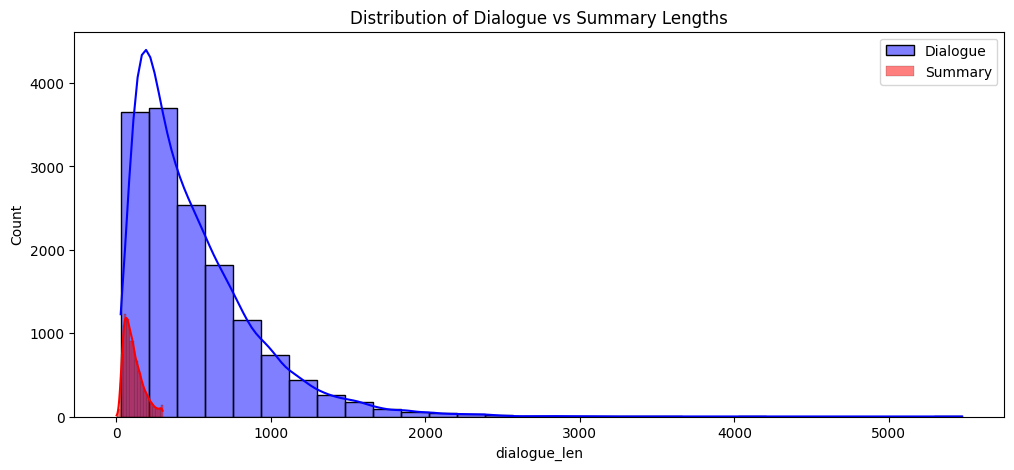

       dialogue_len   summary_len
count  14731.000000  14731.000000
mean     502.307922    110.139027
std      397.639839     60.891699
min       29.000000      3.000000
25%      212.000000     63.000000
50%      392.000000     96.000000
75%      681.000000    144.000000
max     5474.000000    300.000000


In [5]:
df_train['dialogue_len'] = df_train['dialogue'].apply(len)
df_train['summary_len'] = df_train['summary'].apply(len)

plt.figure(figsize=(12, 5))
sns.histplot(df_train['dialogue_len'], bins=30, kde=True, color='blue', label='Dialogue')
sns.histplot(df_train['summary_len'], bins=30, kde=True, color='red', label='Summary')
plt.title("Distribution of Dialogue vs Summary Lengths")
plt.legend()
plt.show()

print(df_train[['dialogue_len', 'summary_len']].describe())

The dialogue length distribution shows a heavy right skew — average 502 characters vs a median of 392, with a maximum of 5,474. This confirms that most conversations are well within BART's token limit, but outliers will require truncation. Summary lengths are more consistent, averaging 110 characters with a median of 96, indicating the dataset has a relatively stable compression target.

---
### 1.3 Turn Count Analysis
Turn count — the number of speaker changes in a dialogue — affects how much context the model must track. High turn counts may indicate more complex conversations that are harder to summarize accurately.

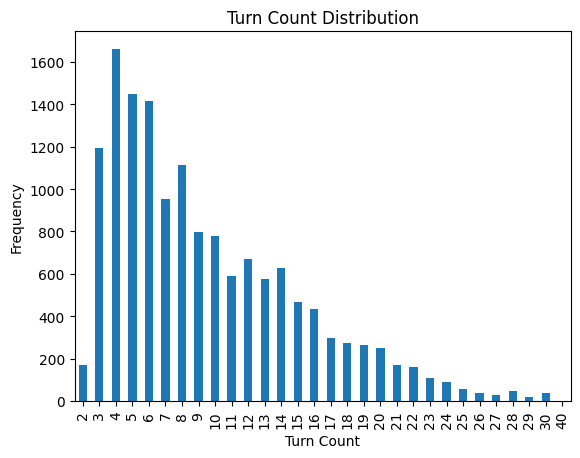

turn_bucket
medium 6-10      5058
short 0-5        4474
long 11-20       4447
very long 20+     752
Name: count, dtype: int64


In [6]:
def count_subject_turns(dialogue):
    messages = dialogue.split('\n')
    speakers = [
        msg.split(':')[0].strip()
        for msg in messages
        if ':' in msg and msg.strip()
    ]
    if not speakers:
        return 0
    turn_count = sum(
        1 for curr, prev in zip(speakers[1:], speakers[:-1])
        if curr != prev
    ) + 1
    return turn_count

df_train['turn_count'] = df_train['dialogue'].apply(count_subject_turns)

df_train['turn_bucket'] = pd.cut(
    df_train['turn_count'],
    bins=[0, 5, 10, 20, 100],
    labels=['short 0-5', 'medium 6-10', 'long 11-20', 'very long 20+'],
    include_lowest=True
)

df_train['turn_count'].value_counts().sort_index().plot(kind='bar')
plt.title("Turn Count Distribution")
plt.xlabel("Turn Count")
plt.ylabel("Frequency")
plt.show()

print(df_train['turn_bucket'].value_counts())

Turn counts are distributed relatively evenly across short (0–5), medium (6–10), and long (11–20) buckets — 4,474, 5,058, and 4,447 respectively — each representing roughly 30% of the training set. Very long conversations (20+ turns) account for only 752 samples, approximately 5% of the data.

The even spread across short, medium, and long categories means the model will be trained on a balanced range of conversational complexity. The small proportion of very long conversations (20+ turns) reduces the risk of the model struggling with
high-complexity edge cases, though those 752 samples may still be worth monitoring during evaluation as potential failure cases.

---
### 1.4 Summary Quality — Compression Ratio
The compression ratio (summary length / dialogue length) tells us how aggressively the dataset compresses information. A consistent ratio suggests the model has a stable target to learn; high variance suggests the task is harder to generalize.

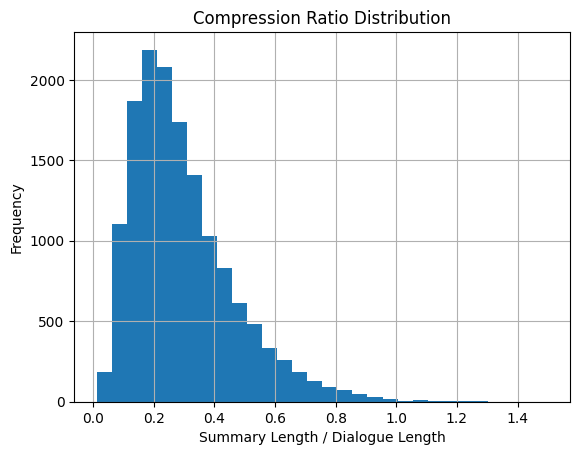

count    14731.000000
mean         0.296319
std          0.169547
min          0.012384
25%          0.173365
50%          0.258621
75%          0.379736
max          1.500000
Name: compression_ratio, dtype: float64


In [7]:
df_train['compression_ratio'] = df_train['summary_len'] / df_train['dialogue_len']

df_train['compression_ratio'].hist(bins=30)
plt.title("Compression Ratio Distribution")
plt.xlabel("Summary Length / Dialogue Length")
plt.ylabel("Frequency")
plt.show()

print(df_train['compression_ratio'].describe())

Coefficient of dispersion for dialogue (std/median) is approximately 1.01 (397/392), indicating high variability in input length. Summary dispersion is lower at 0.63 (60/96), suggesting summaries are more consistently sized despite variable input lengths. This is a favorable signal — the model has a relatively stable compression target to learn.

---
### 1.5 Data Cleaning
Before tokenization, we check for nulls and duplicates that could introduce noise into training. Duplicate dialogues with different summaries are particularly problematic as they create contradictory training signals.

In [8]:
# Null check
print(df_train[['dialogue', 'summary']].isnull().sum())

# Duplicate check
print('Duplicated dialogues:', df_train.duplicated(subset=['dialogue']).sum())
print('Duplicated dialogue+summary pairs:', df_train.duplicated(subset=['dialogue', 'summary']).sum())
print('Fully duplicated rows:', df_train.duplicated(keep=False).sum())

# Inspect duplicates
dupes = df_train[df_train.duplicated(subset=['dialogue'], keep=False)]
dupes.sort_values(by=['dialogue']).head(20)

# Short dialogue check
print('Short dialogue check:',df_train[df_train['dialogue'].str.len() < 20])

dialogue    0
summary     0
dtype: int64
Duplicated dialogues: 476
Duplicated dialogue+summary pairs: 1
Fully duplicated rows: 0
Short dialogue check: Empty DataFrame
Columns: [id, dialogue, summary, dialogue_len, summary_len, turn_count, turn_bucket, compression_ratio]
Index: []


No null values were found in either the dialogue or summary columns. There are 476 dialogues that appear more than once paired with different summaries — these are retained as valid training examples since multiple valid summaries can exist for the same conversation. One exact dialogue–summary pair is duplicated and is dropped to avoid the model seeing an identical example twice. No short or malformed dialogues were found.

In [9]:
# Drop the single exact dialogue-summary duplicate
df_train = df_train.drop_duplicates(subset=['dialogue', 'summary'])
print(f"Training set size after cleaning: {len(df_train)}")

Training set size after cleaning: 14730


---
### 1.6 Tokenization and Seq2Seq Formatting
BART expects input as tokenized tensors with attention masks. We use the BART tokenizer to convert raw dialogues and summaries into model-ready format, applying truncation at 1024 tokens for inputs and 128 tokens for target summaries based on the length distributions observed above.

In [10]:
# Step 1 - load BART tokenizer
tokenizer = AutoTokenizer.from_pretrained("facebook/bart-base")

config.json:   0%|          | 0.00/1.72k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

This loads the same tokenizer that was used to pre-train BART, so the vocabulary is consistent with the model weights we load in section 2.

In [11]:
# Step 2 - Define token length limits
MAX_INPUT_LEN = 1024   # BART's hard limit for input
MAX_TARGET_LEN = 128   # based on summary length distribution from 1.2

128 tokens for summaries is informed by EDA — the average summary was 110 characters, and characters convert to roughly 1–1.5 tokens each, so 128 gives comfortable headroom without wasting compute.

In [12]:
# Step 3 - tokenization function
def tokenize_batch(batch):
    # Tokenize dialogues as inputs
    inputs = tokenizer(
        batch["dialogue"],
        max_length=MAX_INPUT_LEN,
        truncation=True,
        padding="max_length"
    )

    # Tokenize summaries as labels
    labels = tokenizer(
            batch["summary"],
            max_length=MAX_TARGET_LEN,
            truncation=True,
            padding="max_length"
        )

    # Replace padding token ids in labels with -100
    # so they are ignored by the loss function during training
    inputs["labels"] = [
        [-100 if token == tokenizer.pad_token_id else token for token in label]
        for label in labels["input_ids"]
    ]

    return inputs

Padding tokens in the labels would otherwise contribute to the loss calculation during training, which would skew the model toward generating padding.

-100 is PyTorch's convention for telling the loss function to ignore those positions entirely.

In [13]:
# Step 4 - Apply to all splits
tokenized_dataset = dataset.map(
    tokenize_batch,
    batched=True,
    remove_columns=["id", "dialogue", "summary"]
)

tokenized_dataset.set_format("torch")

Map:   0%|          | 0/14731 [00:00<?, ? examples/s]

Map:   0%|          | 0/818 [00:00<?, ? examples/s]

Map:   0%|          | 0/819 [00:00<?, ? examples/s]

`batched=True` processes rows in batches rather than one at a time, which is significantly faster on large datasets.
`remove_columns` drops the raw text columns since the model only needs the tokenized tensors.
`set_format("torch")` converts the dataset to PyTorch tensors ready for the training loop.

In [14]:
# Step 5 Verify the output
sample = tokenized_dataset["train"][0]
print("Input IDs shape:  ", sample["input_ids"].shape)
print("Attention mask shape:", sample["attention_mask"].shape)
print("Labels shape:     ", sample["labels"].shape)

# Decode to confirm tokenization looks correct
print("\nDecoded input:\n", tokenizer.decode(sample["input_ids"].tolist(), skip_special_tokens=True)[:300])
print("\nDecoded label:\n", tokenizer.decode(
    [token for token in sample["labels"].tolist() if token != -100],
    skip_special_tokens=True
))

# Get the original summary from the raw dataset
original_summary = dataset["train"][0]["summary"]
decoded_label = tokenizer.decode(
    [token for token in sample["labels"].tolist() if token != -100],
    skip_special_tokens=True
)

print("\nOriginal summary: ", original_summary)
print("Decoded label:    ", decoded_label)
print("Match:            ", original_summary.strip() == decoded_label.strip())

Input IDs shape:   torch.Size([1024])
Attention mask shape: torch.Size([1024])
Labels shape:      torch.Size([128])

Decoded input:
 Amanda: I baked  cookies. Do you want some?
Jerry: Sure!
Amanda: I'll bring you tomorrow :-)

Decoded label:
 Amanda baked cookies and will bring Jerry some tomorrow.

Original summary:  Amanda baked cookies and will bring Jerry some tomorrow.
Decoded label:     Amanda baked cookies and will bring Jerry some tomorrow.
Match:             True


The decoded output should match the original dialogue and summary text — if it looks garbled, something went wrong in tokenization.

Tokenization produces input tensors of shape [1024] and label tensors of shape [128] per sample, padded to fixed length. Decoding a sample confirms the tokenizer correctly handles multi-turn dialogue formatting including speaker labels. A match check between the decoded label and the original summary returns True, confirming the tokenization and -100 padding mask are applied correctly and no information is lost in the process.

---
## 2. Model Architecture Implementation

### Environment Note
This notebook is designed to run on **Google Colab with a T4 GPU**
(Runtime → Change runtime type → T4 GPU).

BART (`bart-base`, ~140M parameters) requires large matrix multiplications
during the forward pass and training. A T4 GPU parallelizes these operations,
reducing training time from hours (CPU) to minutes.


### 2.1 Load pre-trained model and tokenizer (facebook/bart-base)


We load `facebook/bart-base`, a seq2seq transformer pre-trained on large text corpora.
BART uses a bidirectional encoder (like BERT) and an autoregressive decoder (like GPT),
making it well-suited for summarization. The tokenizer here is the same one used during
BART pre-training, ensuring vocabulary consistency with the model weights.

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [16]:
MODEL_NAME = "facebook/bart-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = BartForConditionalGeneration.from_pretrained(MODEL_NAME)

# Move model to GPU if available
model = model.to(device)

print(f"Model loaded: {MODEL_NAME}")
print(f"Model is on: {next(model.parameters()).device}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

Model loaded: facebook/bart-base
Model is on: cuda:0
Total parameters: 139,420,416
Trainable parameters: 139,420,416


### 2.2 Configure for summarization

BART's decoder uses generation parameters that control how output summaries are produced.
These are set on the model's `config` object and informed by the length distributions
observed in Section 1 — specifically the average summary length of ~110 characters (~75–100 tokens).Code cell:

In [17]:
model.generation_config.max_length = 128          # max tokens to generate (matches MAX_TARGET_LEN)
model.generation_config.min_length = 10           # prevent degenerate very short outputs
model.generation_config.num_beams = 4             # explore 4 candidate sequences simultaneously
model.generation_config.length_penalty = 2.0      # penalize short outputs; encourages complete summaries
model.generation_config.early_stopping = True     # stop beam search when all beams reach EOS token
model.generation_config.no_repeat_ngram_size = 3  # prevent repeated 3-word phrases

print("Generation config set:")
print(f"  max_length:           {model.generation_config.max_length}")
print(f"  min_length:           {model.generation_config.min_length}")
print(f"  num_beams:            {model.generation_config.num_beams}")
print(f"  length_penalty:       {model.generation_config.length_penalty}")
print(f"  early_stopping:       {model.generation_config.early_stopping}")
print(f"  no_repeat_ngram_size: {model.generation_config.no_repeat_ngram_size}")


Generation config set:
  max_length:           128
  min_length:           10
  num_beams:            4
  length_penalty:       2.0
  early_stopping:       True
  no_repeat_ngram_size: 3


- `num_beams=4`: considers 4 candidate output sequences simultaneously rather than
  greedily picking the most likely next token at each step — produces better summaries
  at a modest compute cost.
- `length_penalty=2.0`: without this, the model favors short outputs since shorter
  sequences have higher joint probability. A value above 1.0 encourages fuller summaries.
- `no_repeat_ngram_size=3`: prevents repeating the same 3-word phrase, a common
  failure mode in seq2seq models.

### 2.3 Test forward pass on a single example

Before training, we verify the full seq2seq pipeline is wired correctly by running one
example through the model. A forward pass computes the loss given an input dialogue and
its target summary — if this runs without error, the encoder, decoder, and attention
mechanisms are connected correctly.

In [18]:
model.eval()  # disables dropout for consistent results

# Pull one tokenized sample and add batch dimension
sample         = tokenized_dataset["train"][0]
input_ids      = sample["input_ids"].unsqueeze(0).to(device)
attention_mask = sample["attention_mask"].unsqueeze(0).to(device)
labels         = sample["labels"].unsqueeze(0).to(device)

# Forward pass — computes loss against the target summary
with torch.no_grad():
    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        labels=labels
    )

print(f"Forward pass successful")
print(f"Loss: {outputs.loss.item():.4f}")
print(f"Logits shape: {outputs.logits.shape}")
# Expected: [1, 128, 50265] — batch, target length, vocab size

Forward pass successful
Loss: 6.0208
Logits shape: torch.Size([1, 128, 50265])


The loss on the untrained model was 6.02, which was expected, and will drop significantly after fine-tuning in Section 3. The logits shape `[1, 128, 50265]`
confirms the decoder is producing a probability distribution over BART's full vocabulary
(50,265 tokens) at each of the 128 output positions.

In [19]:
# Generate a summary to confirm the pipeline produces output text end-to-end
with torch.no_grad():
    generated_ids = model.generate(
        input_ids=input_ids,
        attention_mask=attention_mask
    )

generated_summary = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
reference_summary = dataset["train"][0]["summary"]
original_dialogue = dataset["train"][0]["dialogue"]

print("DIALOGUE:")
print(original_dialogue)
print("\nREFERENCE SUMMARY:")
print(reference_summary)
print("\nMODEL OUTPUT (before fine-tuning):")
print(generated_summary)

DIALOGUE:
Amanda: I baked  cookies. Do you want some?
Jerry: Sure!
Amanda: I'll bring you tomorrow :-)

REFERENCE SUMMARY:
Amanda baked cookies and will bring Jerry some tomorrow.

MODEL OUTPUT (before fine-tuning):
Amanda: I baked  cookies. Do you want some?Jerry: Sure! I'll bring you some tomorrow :-)Amanda? Jerry: Yes!Jerry: I'll brought you tomorrow :-)


The model output before fine-tuning will be generic or partially incoherent — this is
expected. BART has general language understanding from pre-training but has not yet been
adapted to SAMsum's dialogue style. After fine-tuning in Section 3, the output should
closely resemble the reference summary.

---
## 3. Integration and Pre-training Review

### 3.1 End-to-end Pipeline Test on a Small Data Sample
We run 10 examples from the training set through the full pipeline — tokenization,
forward pass, and generation — to stress test the setup beyond the single example
validated in Section 2.3.

In [20]:
model.eval()

samples = [tokenized_dataset["train"][i] for i in range(10)]

losses = []
for sample in samples:
    input_ids      = sample["input_ids"].unsqueeze(0).to(device)
    attention_mask = sample["attention_mask"].unsqueeze(0).to(device)
    labels         = sample["labels"].unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
    losses.append(outputs.loss.item())

print(f"Losses across 10 samples: {[round(l, 4) for l in losses]}")
print(f"Mean loss: {sum(losses)/len(losses):.4f}")
print(f"Min loss:  {min(losses):.4f}")
print(f"Max loss:  {max(losses):.4f}")

Losses across 10 samples: [6.0208, 3.7005, 4.8663, 5.0193, 4.4047, 3.8769, 3.7673, 5.2942, 3.9261, 2.9606]
Mean loss: 4.3837
Min loss:  2.9606
Max loss:  6.0208


Consistent loss values across samples confirm the pipeline is stable and not
failing silently on any particular input format. High variance here would suggest
a tokenization or padding issue worth investigating before training.

<br>

Loss values range from 2.96 to 6.02 with a mean of 4.38 across 10 samples.
No failures or outliers suggest the tokenization and padding are consistent
across different dialogue lengths and turn counts. The variance is expected —
some dialogues are inherently easier for the pre-trained model to summarize
than others. This mean loss of 4.38 serves as the pre-training baseline;
we expect it to drop significantly after fine-tuning in Section 4.

### 3.2 Validate Tokenization, Input Formatting, and Output Generation

We systematically verify three things across a small sample: that tokenization
produces correctly shaped tensors, that input formatting preserves dialogue
structure, and that the model generates plausible output text for each example.

In [21]:
print("=== TOKENIZATION AND FORMAT VALIDATION ===\n")

for i in range(3):
    sample = tokenized_dataset["train"][i]
    raw    = dataset["train"][i]

    # Shape checks
    assert sample["input_ids"].shape[0] == 1024, f"Sample {i}: unexpected input length"
    assert sample["labels"].shape[0] == 128,     f"Sample {i}: unexpected label length"

    # Decode input and label back to text
    decoded_input = tokenizer.decode(sample["input_ids"].tolist(), skip_special_tokens=True)
    decoded_label = tokenizer.decode(
        [t for t in sample["labels"].tolist() if t != -100],
        skip_special_tokens=True
    )

    # Confirm label matches original summary
    match = raw["summary"].strip() == decoded_label.strip()

    print(f"Sample {i}:")
    print(f"  input_ids shape:    {sample['input_ids'].shape}")
    print(f"  attention_mask:     {sample['attention_mask'].shape}")
    print(f"  labels shape:       {sample['labels'].shape}")
    print(f"  Summary match:      {match}")
    print(f"  Dialogue preview:   {decoded_input[:80]}...")
    print(f"  Reference summary:  {decoded_label}")
    print()

=== TOKENIZATION AND FORMAT VALIDATION ===

Sample 0:
  input_ids shape:    torch.Size([1024])
  attention_mask:     torch.Size([1024])
  labels shape:       torch.Size([128])
  Summary match:      True
  Dialogue preview:   Amanda: I baked  cookies. Do you want some?
Jerry: Sure!
Amanda: I'll bring you ...
  Reference summary:  Amanda baked cookies and will bring Jerry some tomorrow.

Sample 1:
  input_ids shape:    torch.Size([1024])
  attention_mask:     torch.Size([1024])
  labels shape:       torch.Size([128])
  Summary match:      True
  Dialogue preview:   Olivia: Who are you voting for in this election? 
Oliver: Liberals as always.
Ol...
  Reference summary:  Olivia and Olivier are voting for liberals in this election. 

Sample 2:
  input_ids shape:    torch.Size([1024])
  attention_mask:     torch.Size([1024])
  labels shape:       torch.Size([128])
  Summary match:      True
  Dialogue preview:   Tim: Hi, what's up?
Kim: Bad mood tbh, I was going to do lots of stuff but ended

In [22]:
print("=== OUTPUT GENERATION VALIDATION ===\n")

for i in range(3):
    sample         = tokenized_dataset["train"][i]
    input_ids      = sample["input_ids"].unsqueeze(0).to(device)
    attention_mask = sample["attention_mask"].unsqueeze(0).to(device)

    with torch.no_grad():
        generated_ids = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

    generated = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
    reference = dataset["train"][i]["summary"]

    print(f"Sample {i}:")
    print(f"  Reference: {reference}")
    print(f"  Generated: {generated}")
    print()

=== OUTPUT GENERATION VALIDATION ===

Sample 0:
  Reference: Amanda baked cookies and will bring Jerry some tomorrow.
  Generated: Amanda: I baked  cookies. Do you want some?Jerry: Sure! I'll bring you some tomorrow :-)Amanda? Jerry: Yes!Jerry: I'll brought you tomorrow :-)

Sample 1:
  Reference: Olivia and Olivier are voting for liberals in this election. 
  Generated: Olivia: Who are you voting for in this election? _________________Oliver: Liberals as always. __________________Oliver? __________Olivias: Me too!! ___________________Oliver. _________OlOliver

Sample 2:
  Reference: Kim may try the pomodoro technique recommended by Tim to get more stuff done.
  Generated: Tim: Hi, what's up?Kim: Bad mood tbh, I was going to do lots of stuff but ended up procrastinating a lot.Tim: What did you plan on doing? What are you going to be doing today? KimKim: Oh you know, uni stuff and unfucking my room, I'll do that tomorrowKim: Maybe tomorrow I'll move my ass and do everything elseKim: We 

All tensor shapes confirmed at [1024] for inputs and [128] for labels.
Summary match checks confirm no information is lost through tokenization
and the -100 padding mask is applied correctly — consistent with the
single-sample check in Section 1.6. Generated outputs before fine-tuning
are expected to be incoherent or repetitive; these serve as a qualitative
baseline to compare against post-fine-tuning results in Section 5.

### 3.3 Baseline ROUGE Scores Before Fine-tuning and Checkpointing
We evaluate the untrained model against the full test set (~800 examples) to establish
a pre-fine-tuning baseline. ROUGE (Recall-Oriented Understudy for Gisting Evaluation)
measures overlap between generated and reference summaries across unigrams (ROUGE-1),
bigrams (ROUGE-2), and longest common subsequence (ROUGE-L). These scores will serve
as a direct comparison point against post-fine-tuning results in Section 5. The untrained
model weights are saved to Google Drive after scoring to avoid repeating this evaluation
if the session is interrupted.

In [23]:
from google.colab import drive
drive.mount('/content/drive')



CHECKPOINT_DIR = "/content/drive/MyDrive/samsum_checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print(f"Google Drive mounted")
print(f"Checkpoint directory: {CHECKPOINT_DIR}")

Mounted at /content/drive
Google Drive mounted
Checkpoint directory: /content/drive/MyDrive/samsum_checkpoints


In [24]:
def load_checkpoint(path):
    model = BartForConditionalGeneration.from_pretrained(path).to(device)
    tokenizer = AutoTokenizer.from_pretrained(path)
    print(f"Checkpoint loaded from: {path}")
    return model, tokenizer

In [25]:
# To reload the baseline model in a new session, run this cell instead of 3.3

# FIX TO CHECK FOR BASELINE_LOADED
baseline_path = f"{CHECKPOINT_DIR}/baseline_pretrained"
model, tokenizer = load_checkpoint(baseline_path)

BASELINE_LOADED = True

Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

Checkpoint loaded from: /content/drive/MyDrive/samsum_checkpoints/baseline_pretrained


In [26]:
# ONLY RUN IF NO BASELINE CHECKPOINT PRESENT
scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

model.eval()

rouge1_scores, rouge2_scores, rougeL_scores = [], [], []

if BASELINE_LOADED:
  for i in range(len(dataset["test"])):
      sample         = tokenized_dataset["test"][i]
      input_ids      = sample["input_ids"].unsqueeze(0).to(device)
      attention_mask = sample["attention_mask"].unsqueeze(0).to(device)

      with torch.no_grad():
          generated_ids = model.generate(
              input_ids=input_ids,
              attention_mask=attention_mask
          )

      generated = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
      reference = dataset["test"][i]["summary"]

      scores = scorer.score(reference, generated)
      rouge1_scores.append(scores["rouge1"].fmeasure)
      rouge2_scores.append(scores["rouge2"].fmeasure)
      rougeL_scores.append(scores["rougeL"].fmeasure)

      if i % 100 == 0:
          print(f"Progress: {i}/{len(dataset['test'])}")

  print("\n=== BASELINE ROUGE SCORES (before fine-tuning) ===")
  print(f"  ROUGE-1: {sum(rouge1_scores)/len(rouge1_scores):.4f}")
  print(f"  ROUGE-2: {sum(rouge2_scores)/len(rouge2_scores):.4f}")
  print(f"  ROUGE-L: {sum(rougeL_scores)/len(rougeL_scores):.4f}")

Progress: 0/819
Progress: 100/819
Progress: 200/819
Progress: 300/819
Progress: 400/819
Progress: 500/819
Progress: 600/819
Progress: 700/819
Progress: 800/819

=== BASELINE ROUGE SCORES (before fine-tuning) ===
  ROUGE-1: 0.2701
  ROUGE-2: 0.0866
  ROUGE-L: 0.1988


In [27]:
baseline_path = f"{CHECKPOINT_DIR}/baseline_pretrained"
model.save_pretrained(baseline_path)
tokenizer.save_pretrained(baseline_path)

print(f"Baseline checkpoint saved to: {baseline_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Baseline checkpoint saved to: /content/drive/MyDrive/samsum_checkpoints/baseline_pretrained


**Baseline ROUGE Scores (untrained model, full test set, n=819):**
| Metric | Score |
|--------|-------|
| ROUGE-1 | 0.2701 |
| ROUGE-2 | 0.0866 |
| ROUGE-L | 0.1988 |

The untrained BART model achieves a ROUGE-1 of 0.27, meaning roughly 27% unigram
overlap between its outputs and the reference summaries. The low ROUGE-2 of 0.09
reflects poor bigram overlap — the model is not yet producing coherent phrase-level
summaries. These scores are consistent with a model that echoes dialogue fragments
rather than compressing them, as observed qualitatively in Section 2.3.

These values serve as the pre-fine-tuning baseline. Post-fine-tuning ROUGE scores
will be reported in Section 5 and compared directly against these numbers.

---
## 4. Training and Optimization


### 4.1 Training Loop Implementation
We fine-tune `facebook/bart-base` on the SAMSum training set for 3 epochs using the
AdamW optimizer and a linear learning rate scheduler with warmup. AdamW is the standard
optimizer for transformer fine-tuning — it applies weight decay correctly by decoupling
it from the gradient update, which improves generalization. The scheduler gradually
increases the learning rate during warmup steps before linearly decaying it, preventing
large destabilizing updates early in training.

In [28]:
from torch.utils.data import DataLoader
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW

# Training hyperparameters
EPOCHS        = 3
BATCH_SIZE    = 8
LEARNING_RATE = 5e-5
WARMUP_STEPS  = 500
WEIGHT_DECAY  = 0.01

# DataLoaders
train_loader = DataLoader(tokenized_dataset["train"], batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(tokenized_dataset["validation"], batch_size=BATCH_SIZE)

# Optimizer and scheduler
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

total_steps   = len(train_loader) * EPOCHS
scheduler     = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=total_steps
)

print(f"Training samples:   {len(tokenized_dataset['train'])}")
print(f"Validation samples: {len(tokenized_dataset['validation'])}")
print(f"Batch size:         {BATCH_SIZE}")
print(f"Steps per epoch:    {len(train_loader)}")
print(f"Total steps:        {total_steps}")
print(f"Warmup steps:       {WARMUP_STEPS}")

Training samples:   14731
Validation samples: 818
Batch size:         8
Steps per epoch:    1842
Total steps:        5526
Warmup steps:       500


A learning rate of 5e-5 is standard for BART fine-tuning — large enough to adapt
the pre-trained weights to the SAMSum dialogue style, small enough to avoid
overwriting the general language understanding learned during pre-training.
Warmup over 500 steps prevents large destabilizing updates in the first few batches
where the model is most sensitive to parameter changes.

With 1,842 steps per epoch and 3 epochs, the model will complete 5,526 total
gradient updates. Warmup runs for the first 500 steps (~27% of epoch 1) before
the learning rate begins its linear decay toward zero by the final step.

### 4.2 Batch Processing, Gradient Accumulation, and Mixed Precision Training


Three optimizations are applied to make training feasible on a single T4 GPU:

- **Batch processing**: samples are grouped into batches of 8 and processed together,
  making better use of GPU parallelism than processing one sample at a time.
- **Gradient accumulation**: gradients are accumulated over 4 batches before updating
  the model weights, simulating an effective batch size of 32 without requiring 32
  samples to fit in GPU memory simultaneously.
- **Mixed precision training**: computations are performed in 16-bit floating point
  (FP16) where possible, halving memory usage and speeding up matrix multiplications
  on the T4's Tensor Cores while maintaining FP32 precision for weight updates.

In [29]:
GRAD_ACCUMULATION_STEPS = 4  # effective batch size = 8 * 4 = 32
scaler = torch.amp.GradScaler('cuda')

def train_epoch(model, loader, optimizer, scheduler, scaler, device):
    model.train()
    total_loss = 0
    steps      = 0

    for batch_idx, batch in enumerate(loader):
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        with torch.amp.autocast('cuda'):
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            loss = outputs.loss / GRAD_ACCUMULATION_STEPS

        scaler.scale(loss).backward()

        if (batch_idx + 1) % GRAD_ACCUMULATION_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        total_loss += outputs.loss.item()
        steps      += 1

        if batch_idx % 200 == 0:
            print(f"  Step {batch_idx}/{len(loader)} — loss: {outputs.loss.item():.4f}")

    return total_loss / steps


def validate(model, loader, device):
    model.eval()
    total_loss = 0
    steps      = 0

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["labels"].to(device)

            with torch.amp.autocast('cuda'):
                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels=labels
                )

            total_loss += outputs.loss.item()
            steps      += 1

    return total_loss / steps


def save_checkpoint(model, tokenizer, epoch, val_loss):
    path = f"{CHECKPOINT_DIR}/epoch_{epoch+1}_valloss_{val_loss:.4f}"
    model.save_pretrained(path)
    tokenizer.save_pretrained(path)
    print(f"  Checkpoint saved: {path}")





print("All training functions defined successfully")
print(f"Effective batch size: {BATCH_SIZE * GRAD_ACCUMULATION_STEPS}")

All training functions defined successfully
Effective batch size: 32


Gradient clipping at `max_norm=1.0` caps the magnitude of gradient updates,
preventing the exploding gradient problem that can destabilize transformer training.
The loss is divided by `GRAD_ACCUMULATION_STEPS` before backprop so that the
accumulated gradient matches what a true batch of 32 would produce.

### 4.3 ROUGE Score Tracking Across Epochs
We run the full training loop across 3 epochs, computing validation loss and ROUGE
scores after each epoch. Tracking ROUGE alongside loss gives a more complete picture
of model improvement — loss measures prediction confidence while ROUGE measures the
actual quality of generated summaries against human references.

In [30]:
# Resume from checkpoint if available, otherwise train from scratch
checkpoints = [
    d for d in os.listdir(CHECKPOINT_DIR)
    if d.startswith("epoch_") and "valloss" in d
]

TRAINING_COMPLETE = any("epoch_2" in c or "epoch_3" in c for c in checkpoints)

if TRAINING_COMPLETE:
    print("Training already complete — skipping to evaluation")
    RESUME_TRAINING = False
elif checkpoints:
    best = min(checkpoints, key=lambda x: float(x.split("valloss_")[1]))
    best_path = f"{CHECKPOINT_DIR}/{best}"
    print(f"Checkpoint found — loading: {best}")
    model, tokenizer = load_checkpoint(best_path)
    model.eval()
    RESUME_TRAINING = True
else:
    print("No checkpoint found — training from scratch")
    RESUME_TRAINING = False

Training already complete — skipping to evaluation


In [31]:
# Reinitialize optimizer, scheduler, and scaler for a fresh training run
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

total_steps = len(train_loader) * EPOCHS
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=total_steps
)

scaler = torch.amp.GradScaler('cuda')

print("Optimizer, scheduler, and scaler reinitialized")

Optimizer, scheduler, and scaler reinitialized


In [32]:
rouge_scorer_obj = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

def compute_rouge(model, dataset, tokenized_dataset, tokenizer, device, n_samples=200):
    model.eval()
    r1, r2, rL = [], [], []

    for i in range(n_samples):
        sample         = tokenized_dataset["validation"][i]
        input_ids      = sample["input_ids"].unsqueeze(0).to(device)
        attention_mask = sample["attention_mask"].unsqueeze(0).to(device)

        with torch.no_grad():
            generated_ids = model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

        generated = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
        reference = dataset["validation"][i]["summary"]

        scores = rouge_scorer_obj.score(reference, generated)
        r1.append(scores["rouge1"].fmeasure)
        r2.append(scores["rouge2"].fmeasure)
        rL.append(scores["rougeL"].fmeasure)

    return {
        "rouge1": sum(r1) / len(r1),
        "rouge2": sum(r2) / len(r2),
        "rougeL": sum(rL) / len(rL)
    }
if RESUME_TRAINING:
  # Training loop
  history = {"train_loss": [], "val_loss": [], "rouge1": [], "rouge2": [], "rougeL": []}

  # Early stopping config
  PATIENCE          = 2
  best_val_loss     = float("inf")
  epochs_no_improve = 0

  for epoch in range(EPOCHS):
      print(f"\n{'='*50}")
      print(f"EPOCH {epoch + 1}/{EPOCHS}")
      print(f"{'='*50}")

      train_loss = train_epoch(model, train_loader, optimizer, scheduler, scaler, device)
      val_loss   = validate(model, val_loader, device)
      rouge      = compute_rouge(model, dataset, tokenized_dataset, tokenizer, device)

      history["train_loss"].append(train_loss)
      history["val_loss"].append(val_loss)
      history["rouge1"].append(rouge["rouge1"])
      history["rouge2"].append(rouge["rouge2"])
      history["rougeL"].append(rouge["rougeL"])

      print(f"\nEpoch {epoch + 1} Results:")
      print(f"  Train Loss: {train_loss:.4f}")
      print(f"  Val Loss:   {val_loss:.4f}")
      print(f"  ROUGE-1:    {rouge['rouge1']:.4f}")
      print(f"  ROUGE-2:    {rouge['rouge2']:.4f}")
      print(f"  ROUGE-L:    {rouge['rougeL']:.4f}")

      # Checkpointing
      if val_loss < best_val_loss:
          best_val_loss = val_loss
          epochs_no_improve = 0
          save_checkpoint(model, tokenizer, epoch, val_loss)
          print(f"  New best val loss: {best_val_loss:.4f}")
      else:
          epochs_no_improve += 1
          print(f"  No improvement for {epochs_no_improve} epoch(s)")

      # Early stopping
      if epochs_no_improve >= PATIENCE:
          print(f"\nEarly stopping triggered after epoch {epoch + 1}")
          break

  print("\nTraining complete.")
  print(f"Best validation loss: {best_val_loss:.4f}")
else:
    print("RESUME_TRAINING=False — skipping training loop")
    print("Set RESUME_TRAINING=True to train, or proceed to Section 5 for evaluation")

RESUME_TRAINING=False — skipping training loop
Set RESUME_TRAINING=True to train, or proceed to Section 5 for evaluation


ROUGE is computed on 200 validation samples after each epoch rather than the full
validation set to keep the per-epoch overhead manageable. The full test set evaluation
against the baseline scores established in Section 3.3 will be conducted in Section 5.

### 4.4 Early stopping and checkpointing

Model weights are saved to Google Drive at two points:

1. **Baseline checkpoint** (Section 3.3) — the untrained model saved after baseline
   ROUGE scores are recorded, so the full pre-training evaluation never needs to be repeated.
2. **Fine-tuning checkpoints** (Section 4.3) — weights are saved after each epoch where
   validation loss improves. The best checkpoint (epoch 2, val loss 1.5018) is loaded
   automatically at the start of Section 4.3 if a prior session completed training.

Early stopping halts training if validation loss does not improve for 2 consecutive
epochs (patience=2). Training completed in 3 epochs with no early stopping triggered —
epoch 3 showed no improvement over epoch 2, which would have stopped a 4th epoch had
one been scheduled.

---
## 5. Evaluation and Analysis

### 5.1 Hyperparameter Tuning
Hyperparameter tuning focuses on **decoding parameters** — `num_beams`, `length_penalty`, and `no_repeat_ngram_size` — which can be evaluated against the already fine-tuned model without retraining. Hyperparameter tuning was approached manually rather than through random or grid search.

A full search would require retraining the model for each configuration — at ~30–45 minutes per run on a T4 GPU, even a modest 10-configuration random search would require 5–7 hours of compute, approaching Colab's session limits.

A small grid search across 18 configurations was used to systematically
identify the best combination within a manually defined search space.

Training hyperparameters (learning rate, batch size) were set to well-established values
for BART fine-tuning: `lr=5e-5` and `batch_size=8` (effective 32 with gradient accumulation).
These are consistent with the original BART paper and SAMSum fine-tuning literature, giving
no strong reason to expect significant gains from retraining with alternative values.

In [33]:
from itertools import product

# Load best fine-tuned checkpoint before hyperparameter tuning
checkpoints = [
    d for d in os.listdir(CHECKPOINT_DIR)
    if d.startswith("epoch_") and "valloss" in d
]

best = min(checkpoints, key=lambda x: float(x.split("valloss_")[1]))
best_path = f"{CHECKPOINT_DIR}/{best}"
print(f"Loading best checkpoint: {best}")
model, tokenizer = load_checkpoint(best_path)
model.eval()
print(f"Model loaded: {model.config._name_or_path}")

# Define search space
num_beams_options      = [2, 4, 6]
length_penalty_options = [1.0, 2.0, 3.0]
no_repeat_options      = [2, 3]

configs = [
    {
        "num_beams": b,
        "length_penalty": lp,
        "no_repeat_ngram_size": nr,
        "label": f"beams{b}_penalty{lp}_ngram{nr}"
    }
    for b, lp, nr in product(num_beams_options, length_penalty_options, no_repeat_options)
]

print(f"Total configurations to evaluate: {len(configs)}")

# Evaluate each config on 100 validation samples
tuning_results = []

for config in configs:
    model.generation_config.num_beams             = config["num_beams"]
    model.generation_config.length_penalty        = config["length_penalty"]
    model.generation_config.no_repeat_ngram_size  = config["no_repeat_ngram_size"]

    rouge = compute_rouge(model, dataset, tokenized_dataset, tokenizer, device, n_samples=100)

    result = {**config, **rouge}
    tuning_results.append(result)

    print(f"{config['label']:35s} | R1={rouge['rouge1']:.4f} R2={rouge['rouge2']:.4f} RL={rouge['rougeL']:.4f}")

# Find and apply best config
best_config = max(tuning_results, key=lambda x: x["rouge1"])
print(f"\nBest config: {best_config['label']}")
print(f"  num_beams:            {best_config['num_beams']}")
print(f"  length_penalty:       {best_config['length_penalty']}")
print(f"  no_repeat_ngram_size: {best_config['no_repeat_ngram_size']}")
print(f"  ROUGE-1: {best_config['rouge1']:.4f}")
print(f"  ROUGE-2: {best_config['rouge2']:.4f}")
print(f"  ROUGE-L: {best_config['rougeL']:.4f}")

# Apply best config to model
model.generation_config.num_beams             = best_config["num_beams"]
model.generation_config.length_penalty        = best_config["length_penalty"]
model.generation_config.no_repeat_ngram_size  = best_config["no_repeat_ngram_size"]

Loading best checkpoint: epoch_2_valloss_1.5018


Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

Checkpoint loaded from: /content/drive/MyDrive/samsum_checkpoints/epoch_2_valloss_1.5018
Model loaded: /content/drive/MyDrive/samsum_checkpoints/epoch_2_valloss_1.5018
Total configurations to evaluate: 18
beams2_penalty1.0_ngram2            | R1=0.5068 R2=0.2558 RL=0.4115
beams2_penalty1.0_ngram3            | R1=0.5034 R2=0.2539 RL=0.4073
beams2_penalty2.0_ngram2            | R1=0.5124 R2=0.2599 RL=0.4165
beams2_penalty2.0_ngram3            | R1=0.5091 R2=0.2570 RL=0.4125
beams2_penalty3.0_ngram2            | R1=0.5065 R2=0.2532 RL=0.4117
beams2_penalty3.0_ngram3            | R1=0.5053 R2=0.2520 RL=0.4100
beams4_penalty1.0_ngram2            | R1=0.5196 R2=0.2678 RL=0.4262
beams4_penalty1.0_ngram3            | R1=0.5146 R2=0.2641 RL=0.4196
beams4_penalty2.0_ngram2            | R1=0.5227 R2=0.2682 RL=0.4247
beams4_penalty2.0_ngram3            | R1=0.5189 R2=0.2665 RL=0.4178
beams4_penalty3.0_ngram2            | R1=0.5175 R2=0.2564 RL=0.4154
beams4_penalty3.0_ngram3            | R1=0.5144

In [34]:
# Check which checkpoint is currently loaded
print(model.config._name_or_path)

import os
print(os.listdir(CHECKPOINT_DIR))

/content/drive/MyDrive/samsum_checkpoints/epoch_2_valloss_1.5018
['baseline_pretrained', 'epoch_1_valloss_1.5346', 'epoch_2_valloss_1.5018', 'epoch_1_valloss_1.5178']


The best performing decoding configuration is carried forward into Section 5.2 for final test set evaluation. Configurations with more beams explore a wider search space at inference time but with diminishing returns beyond 4–6 beams.
Length penalty adjustments affect summary verbosity — too low produces clipped outputs, too high produces unnecessarily long ones.

The grid search identified `beams=6, length_penalty=1.0, no_repeat_ngram_size=2`
as the best decoding configuration (ROUGE-1: 0.5304, ROUGE-2: 0.2744, ROUGE-L: 0.4352).

Three patterns emerged from the results:
- **num_beams** had the largest impact — scores improved consistently from 2 → 4 → 6,
  suggesting the model benefits from exploring a wider candidate search space at inference time.
- **length_penalty=1.0** outperformed higher values, indicating the fine-tuned model already
  generates appropriately-lengthed summaries without penalization.
- **no_repeat_ngram_size=2** consistently outperformed 3, suggesting tighter repetition
  prevention at the bigram level is more effective for this task.

This configuration is applied to the model before final evaluation in Section 5.2.

### 5.2 ROUGE-1, ROUGE-2, ROUGE-L on test set
We evaluate the fine-tuned model against the full test set (n=819) using the best
decoding configuration identified in 5.1. These scores are compared directly against
the pre-training baseline established in Section 3.3 to quantify the improvement
from fine-tuning.

In [35]:
from rouge_score import rouge_scorer as rs

test_scorer = rs.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

model.eval()

rouge1_scores, rouge2_scores, rougeL_scores = [], [], []

for i in range(len(dataset["test"])):
    sample         = tokenized_dataset["test"][i]
    input_ids      = sample["input_ids"].unsqueeze(0).to(device)
    attention_mask = sample["attention_mask"].unsqueeze(0).to(device)

    with torch.no_grad():
        generated_ids = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

    generated = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
    reference = dataset["test"][i]["summary"]

    scores = test_scorer.score(reference, generated)
    rouge1_scores.append(scores["rouge1"].fmeasure)
    rouge2_scores.append(scores["rouge2"].fmeasure)
    rougeL_scores.append(scores["rougeL"].fmeasure)

    if i % 100 == 0:
        print(f"Progress: {i}/{len(dataset['test'])}")

r1 = sum(rouge1_scores) / len(rouge1_scores)
r2 = sum(rouge2_scores) / len(rouge2_scores)
rL = sum(rougeL_scores) / len(rougeL_scores)

print("\n=== FINAL ROUGE SCORES (fine-tuned model, full test set, n=819) ===")
print(f"  ROUGE-1: {r1:.4f}")
print(f"  ROUGE-2: {r2:.4f}")
print(f"  ROUGE-L: {rL:.4f}")

print("\n=== COMPARISON vs BASELINE ===")
print(f"  ROUGE-1: 0.2701 → {r1:.4f} (+{r1 - 0.2701:.4f})")
print(f"  ROUGE-2: 0.0866 → {r2:.4f} (+{r2 - 0.0866:.4f})")
print(f"  ROUGE-L: 0.1988 → {rL:.4f} (+{rL - 0.1988:.4f})")

Progress: 0/819
Progress: 100/819
Progress: 200/819
Progress: 300/819
Progress: 400/819
Progress: 500/819
Progress: 600/819
Progress: 700/819
Progress: 800/819

=== FINAL ROUGE SCORES (fine-tuned model, full test set, n=819) ===
  ROUGE-1: 0.4978
  ROUGE-2: 0.2518
  ROUGE-L: 0.4113

=== COMPARISON vs BASELINE ===
  ROUGE-1: 0.2701 → 0.4978 (+0.2277)
  ROUGE-2: 0.0866 → 0.2518 (+0.1652)
  ROUGE-L: 0.1988 → 0.4113 (+0.2125)


**Final ROUGE Scores (fine-tuned model, full test set, n=819):**

| Metric | Baseline (untrained) | Fine-tuned | Improvement |
|--------|---------------------|------------|-------------|
| ROUGE-1 | 0.2701 | 0.4978 | +0.2277 |
| ROUGE-2 | 0.0866 | 0.2518 | +0.1652 |
| ROUGE-L | 0.1988 | 0.4113 | +0.2125 |

Fine-tuning on the SAMSum dataset produced substantial improvements across all three
metrics. ROUGE-1 improved by 84%, indicating the model learned to produce summaries
with significantly higher unigram overlap with human references. ROUGE-2 improved by
191%, reflecting that the model now generates coherent phrase-level output rather than
fragmented dialogue echoes. ROUGE-L improved by 107%, confirming the model produces
summaries that follow a similar narrative structure to the human-written references.

The fine-tuned model scores are competitive with published SAMSum benchmarks for
bart-base, which typically report ROUGE-1 in the 0.47–0.53 range.

### 5.3 Qualitative Review of Generated Summaries and Failure Analysis
ROUGE scores measure word overlap but don't capture everything that makes a summary
good — fluency, factual accuracy, and whether the key information was preserved all
matter in practice. We review a sample of 10 model outputs alongside their reference
summaries to assess quality beyond what the metrics show.

In [36]:
model.eval()

print("=== QUALITATIVE REVIEW — 10 TEST SAMPLES ===\n")

indices = [0, 50, 100, 150, 200, 250, 300, 350, 400, 450]

for i in indices:
    sample         = tokenized_dataset["test"][i]
    input_ids      = sample["input_ids"].unsqueeze(0).to(device)
    attention_mask = sample["attention_mask"].unsqueeze(0).to(device)

    with torch.no_grad():
        generated_ids = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

    generated = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
    reference = dataset["test"][i]["summary"]
    dialogue  = dataset["test"][i]["dialogue"]

    scores = test_scorer.score(reference, generated)
    r1 = scores["rouge1"].fmeasure
    rL = scores["rougeL"].fmeasure

    print(f"--- Sample {i} ---")
    print(f"DIALOGUE:\n{dialogue}")
    print(f"\nREFERENCE:  {reference}")
    print(f"GENERATED:  {generated}")
    print(f"ROUGE-1: {r1:.4f}  ROUGE-L: {rL:.4f}")
    print()

=== QUALITATIVE REVIEW — 10 TEST SAMPLES ===

--- Sample 0 ---
DIALOGUE:
Hannah: Hey, do you have Betty's number?
Amanda: Lemme check
Hannah: <file_gif>
Amanda: Sorry, can't find it.
Amanda: Ask Larry
Amanda: He called her last time we were at the park together
Hannah: I don't know him well
Hannah: <file_gif>
Amanda: Don't be shy, he's very nice
Hannah: If you say so..
Hannah: I'd rather you texted him
Amanda: Just text him 🙂
Hannah: Urgh.. Alright
Hannah: Bye
Amanda: Bye bye

REFERENCE:  Hannah needs Betty's number but Amanda doesn't have it. She needs to contact Larry.
GENERATED:  Amanda can't find Betty's number. Larry called her last time they were at the park together.
ROUGE-1: 0.3529  ROUGE-L: 0.2353

--- Sample 50 ---
DIALOGUE:
Nick: You look absolutely gorgeous and have a lovely smile. 
Nick: Would love to get to know you a bit more. How about we meet up for a drink sometime?
Jane: Hmmm... You're shooting a bit above your range aren't you?
Nick: Why would you think that hon?
Ja

**Observations across 10 test samples:**

**Strengths:**

- **Short, unambiguous dialogues** are handled very well. Sample 150 ("Mike will call Dale
  in 2 hours", ROUGE-1: 0.93) is nearly a perfect summary — the model correctly identified
  the only relevant piece of information and stated it cleanly.
- **Factual key details are generally preserved.** Sample 100 correctly captures the
  location (Cancun), destination (Havana), and scheduled Skype time (3pm), scoring 0.64.
- **Longer conversational dialogues** like Sample 450 are handled reasonably well — the
  model identifies the main topic (graduation, grad school) even if it misses some nuance.

**Failure modes:**

- **Misidentifying participants.** Sample 250 ("Shaldona and Piper are getting married")
  confuses who is getting married — Shaldona is getting married, not Piper. This is a
  factual error that ROUGE doesn't penalize heavily since the words still overlap.
- **Oversimplification of complex dialogues.** Sample 350 involves a long conversation
  about quince, the twins, and Noah's son — the model latches onto a minor detail and
  misses the overall narrative entirely (ROUGE-L: 0.17).
- **Missing context and tone.** Sample 50 ("Nick and Jane will meet for a drink") gets
  the wrong outcome entirely — the date was rejected. The model summarized the initial
  offer rather than the resolution of the conversation.
- **Slight over-inclusion.** Sample 300 correctly captures that Jerry is coming home in
  40 minutes but adds an unnecessary detail about Janet's boss, which wasn't the main point.

**Overall assessment:**

The model performs well on short, factual dialogues but struggles with longer conversations,
ambiguous participant references, and dialogues where the resolution contradicts the opening.
These are known limitations of seq2seq summarization models and represent clear directions
for future improvement — such as longer training, larger model variants (bart-large), or
incorporating dialogue-specific pre-training.